# With SCF vs without SCF

Side-by-side comparison of the two pipeline variants, rendered inline.

This is the notebook version of `pipeline/07_compare.py` — same functions from
`myutils.plots`, so the figures are identical to the ones written to
`{output_dir}/plots_compare/`. Use the script for files, this for looking.

**Prerequisite:** both variants have run —

```bash
python pipeline/run_variants.py --submit
```

producing `{output_dir}/with_SCF/` and `{output_dir}/without_SCF/`.

In [1]:
import os

os.environ['PS_CONFIG'] = '/idia/users/schatterjee/MWA_work/MWA_2026_newwork/new_PS_pipeline/ps_pipeline/config.yaml'

import numpy as np
import matplotlib.pyplot as plt

from myutils.config import load
import myutils.plots as mp

%matplotlib inline
mp.style()

cfg = load()
base = cfg.paths.output_dir

runs = [
    ('with SCF',    base / 'with_SCF'),
    ('without SCF', base / 'without_SCF'),
]

loaded = [(label, mp.load_run(d)) for label, d in runs]
for (label, d), (_, path) in zip(loaded, runs):
    print(f"{label:<14s} NE={int(d['NE']):<4d} sigma={float(d['sigma']):>12.4f}  "
          f"modes={int(d['flag_mask'].sum()):<6d} {path.name}")

Imported myutils
         Of 20 annular bins: 1 fall entirely beyond it and will be empty, 1 straddle it and will be under-filled.
         nside_auto is off, so nside stays 512. To keep every bin either raise nside to >= 546, or lower binning.binUmax to <= 244.
with SCF       NE=668  sigma=      0.5868  modes=488    with_SCF
without SCF    NE=760  sigma=     11.7571  modes=561    without_SCF


## The numbers first

`sigma` is the noise calibration — near 1 means the simulated noise reproduces the
observed scatter. A huge value means the data is dominated by something the noise
model does not describe, which for unfiltered data is the foregrounds.

In [2]:
for label, d in loaded:
    print(f"=== {label} ===")
    print(f"  sigma_est {float(d['sigma']):.4f}    mu_est {float(d['mu']):.4f}")
    print(f"  {'k [1/Mpc]':>11}  {'Delta^2':>13}  {'2 sigma':>13}  {'SNR':>8}  {'upper limit':>13}")
    for i in range(len(d['kk'])):
        print(f"  {d['kk'][i]:11.4f}  {d['dk2'][i]:13.3e}  {d['dpk2'][i]:13.3e}"
              f"  {d['snr'][i]:8.3f}  {d['ul'][i]:13.3e}")
    print()

=== with SCF ===
  sigma_est 0.5868    mu_est 0.0830
    k [1/Mpc]        Delta^2        2 sigma       SNR    upper limit
       0.1775      9.234e+04      1.444e+04    12.792      1.068e+05
       0.2353      6.141e+04      5.832e+04     2.106      1.197e+05
       0.4449      2.417e+05      1.825e+05     2.649      4.242e+05
       0.5213      7.550e+05      4.356e+05     3.466      1.191e+06
       0.9457     -4.748e+05      1.263e+06    -0.752      1.263e+06
       1.3372      9.663e+05      2.852e+06     0.678      3.818e+06

=== without SCF ===
  sigma_est 11.7571    mu_est 0.5305
    k [1/Mpc]        Delta^2        2 sigma       SNR    upper limit
       0.1937      8.052e+05      3.856e+05     4.177      1.191e+06
       0.2391      1.782e+06      1.285e+06     2.773      3.067e+06
       0.4512     -2.179e+06      3.948e+06    -1.104      3.948e+06
       0.5227      7.255e+05      9.294e+06     0.156      1.002e+07
       0.9454      3.147e+06      2.276e+07     0.277      2.

## 1 · Spherical power spectrum

Both variants overlaid. Filled markers are detections; hollow markers with a
downward arrow are consistent with zero, i.e. upper limits.

The two runs sample **different $k$** — SCF trims $2N_W$ channels, so the binning
differs slightly. They are the same field through two analyses, not two
measurements on one grid.

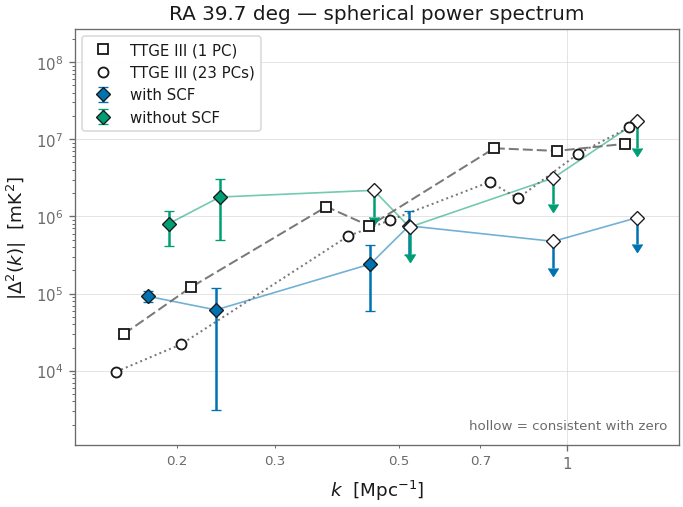

In [3]:
REFERENCE = cfg.plots.get('reference') or None   # published limits, from the config
mp.compare_spherical(loaded, title='RA 39.7 deg — spherical power spectrum',
                     reference=REFERENCE)

## 2 · Cylindrical power spectrum

**One shared colour scale across both panels** — that is the whole point. Letting
each panel autoscale would renormalise away the suppression the figure exists to
show. The dashed line is the foreground wedge.

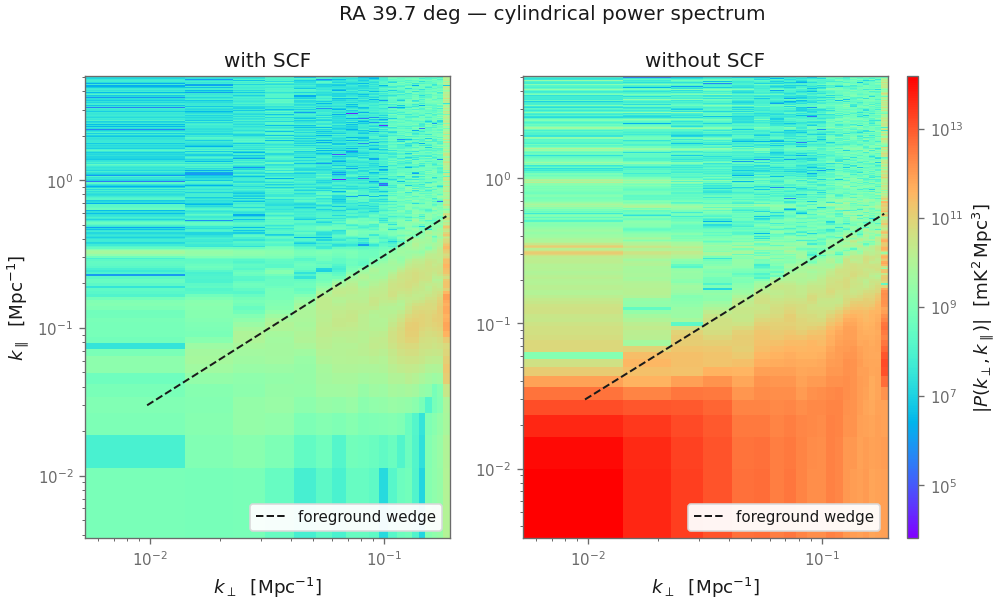

In [4]:
mp.compare_cylindrical(loaded, title='RA 39.7 deg — cylindrical power spectrum')

In [5]:
# how much does SCF suppress, bin by bin?
a = np.abs(loaded[0][1]['pk'])          # with SCF
b = np.abs(loaded[1][1]['pk'])          # without SCF
n = min(a.shape[-1], b.shape[-1])       # different NE -> compare the common range
with np.errstate(divide='ignore', invalid='ignore'):
    ratio = np.nanmedian(b[..., :n] / a[..., :n])
print(f'median |P| suppression (without/with SCF): {ratio:.3e}')

median |P| suppression (without/with SCF): 2.126e+00


## 3 · Cuts at fixed $k_\perp$

The cross-section pages of `Documentation/RA_11.pdf`. Grey bands mark the
$k_\parallel$ ranges that enter the spherical average; the dashed vertical line is
the lower edge of the first window. Each legend entry carries its own $N_E$, since
the runs sample different $k_\parallel$.

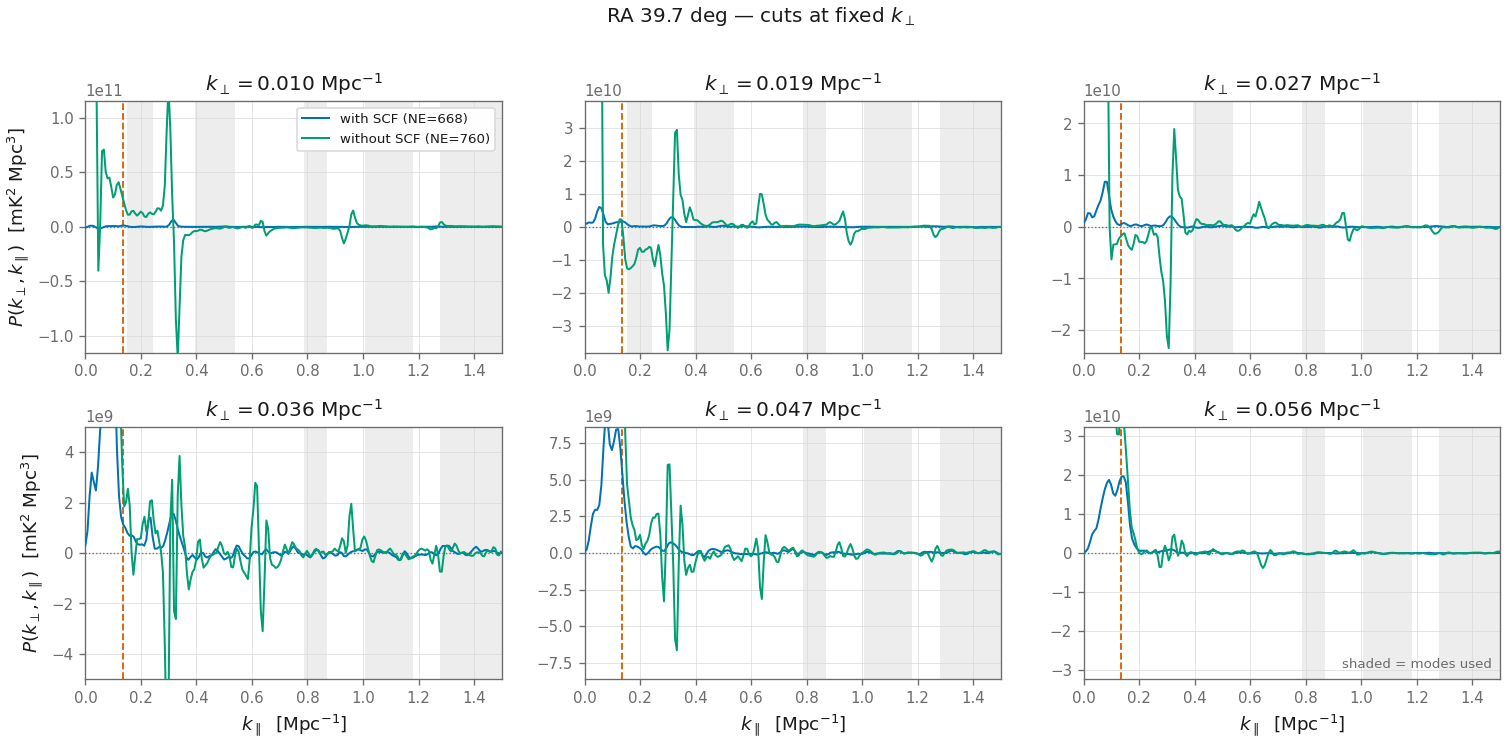

In [6]:
ranges = cfg.power_spectrum.get('kpara_ranges') or []
mp.pk_cross_sections(loaded,
                     reference=float(ranges[0]) if ranges else None,
                     title=r'RA 39.7 deg — cuts at fixed $k_\perp$')

## 4 · $C_\ell(\Delta\nu)$

The multi-frequency angular power spectrum, one panel per $\ell$ bin. Without SCF
this is dominated by the smooth foreground component; with SCF that component has
been subtracted and what remains should look like noise.

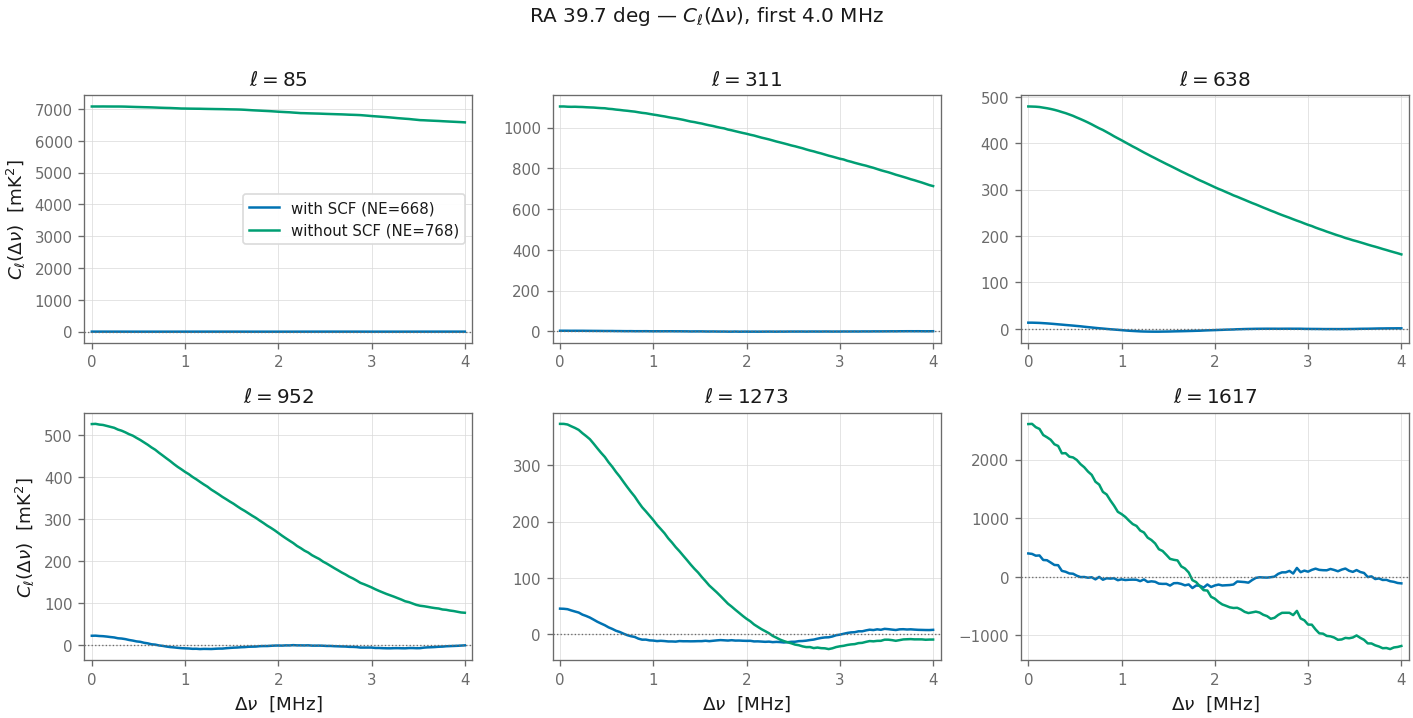

In [7]:
MAX_DNU = 4.0        # MHz shown on the Delta-nu axis

cl_runs = [(label, mp.load_cl(d)) for label, d in runs]
lval = np.load(sorted((runs[0][1]).glob('bin_info_*.npz'))[0])['lval']

mp.cl_dnu_panels(cl_runs, lval, cfg.observation.dnuc_mhz, max_dnu=MAX_DNU,
                 title=rf'RA 39.7 deg — $C_\ell(\Delta\nu)$, first {MAX_DNU} MHz')

### 4a · One variant on its own

Both curves share each panel's y-scale above, and `without SCF` is 100–1000x
larger — so `with SCF` is squashed to a flat line near zero and its structure is
unreadable at low $\ell$. Plot it alone to see it.

Set `PICK` to whichever variant you want.

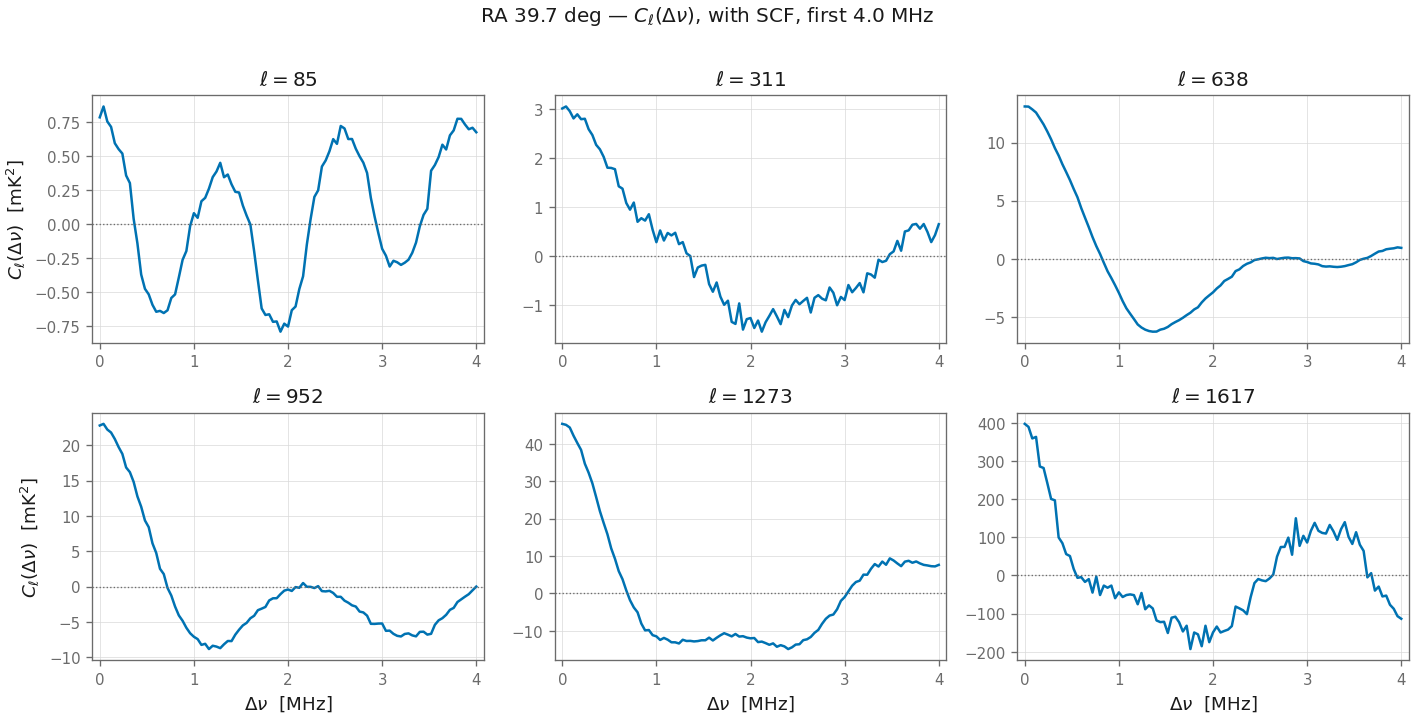

In [8]:
PICK = 'with SCF'        # or 'without SCF'

sel = [(l, d) for l, d in runs if l == PICK]
if not sel:
    raise ValueError(f'{PICK!r} not found. Available: {[l for l, _ in runs]}')

cl_one = [(l, mp.load_cl(d)) for l, d in sel]
# lval from the variant actually being plotted, not always runs[0]
lval_one = np.load(sorted(sel[0][1].glob('bin_info_*.npz'))[0])['lval']

mp.cl_dnu_panels(cl_one, lval_one, cfg.observation.dnuc_mhz, max_dnu=MAX_DNU,
                 title=rf'RA 39.7 deg — $C_\ell(\Delta\nu)$, {PICK}, '
                       rf'first {MAX_DNU} MHz')

## 5 · $C_\ell(\nu_a,\nu_b)$ — two columns, left without SCF

One row per $\ell$ bin. Choose which bins with **either**:

| argument | meaning |
|---|---|
| `n_bins=5` | the first 5 bins |
| `bins=[2, 6, 10]` | exactly those bins |
| `bins=range(0, 20, 4)` | every fourth |
| neither | all of them (~25 MB — prefer a subset inline) |

`drop_flagged=True` removes flagged channels rather than leaving them as blank
lattice lines. A flagged channel is zeroed at gridding, so its whole row and
column are empty; excising them makes the map continuous. The axes then run
over *retained channel*, tick-labelled with the real frequency — plotting
against $\nu$ would put the gaps straight back.

**Each panel keeps its own colourbar.** The unfiltered MAPS is ~200x larger, so
a shared scale would render the filtered panel flat. That is the opposite of the
cylindrical figure, where one shared scale is the entire point.

In [9]:
cl2d_runs = [
    ('without SCF', mp.load_cl(base / 'without_SCF', kind='cl2d')),
    ('with SCF',    mp.load_cl(base / 'with_SCF',    kind='cl2d')),
]

for label, arr in cl2d_runs:
    keep = mp.unflagged_channels(np.asarray(arr[0], float))
    print(f'{label:<14s} {arr.shape}   unflagged {keep.size}/{arr.shape[-1]}'
          f'   ({arr.shape[-1] - keep.size} flagged channels removed)')

without SCF    (20, 768, 768)   unflagged 552/768   (216 flagged channels removed)
with SCF       (20, 668, 668)   unflagged 480/668   (188 flagged channels removed)


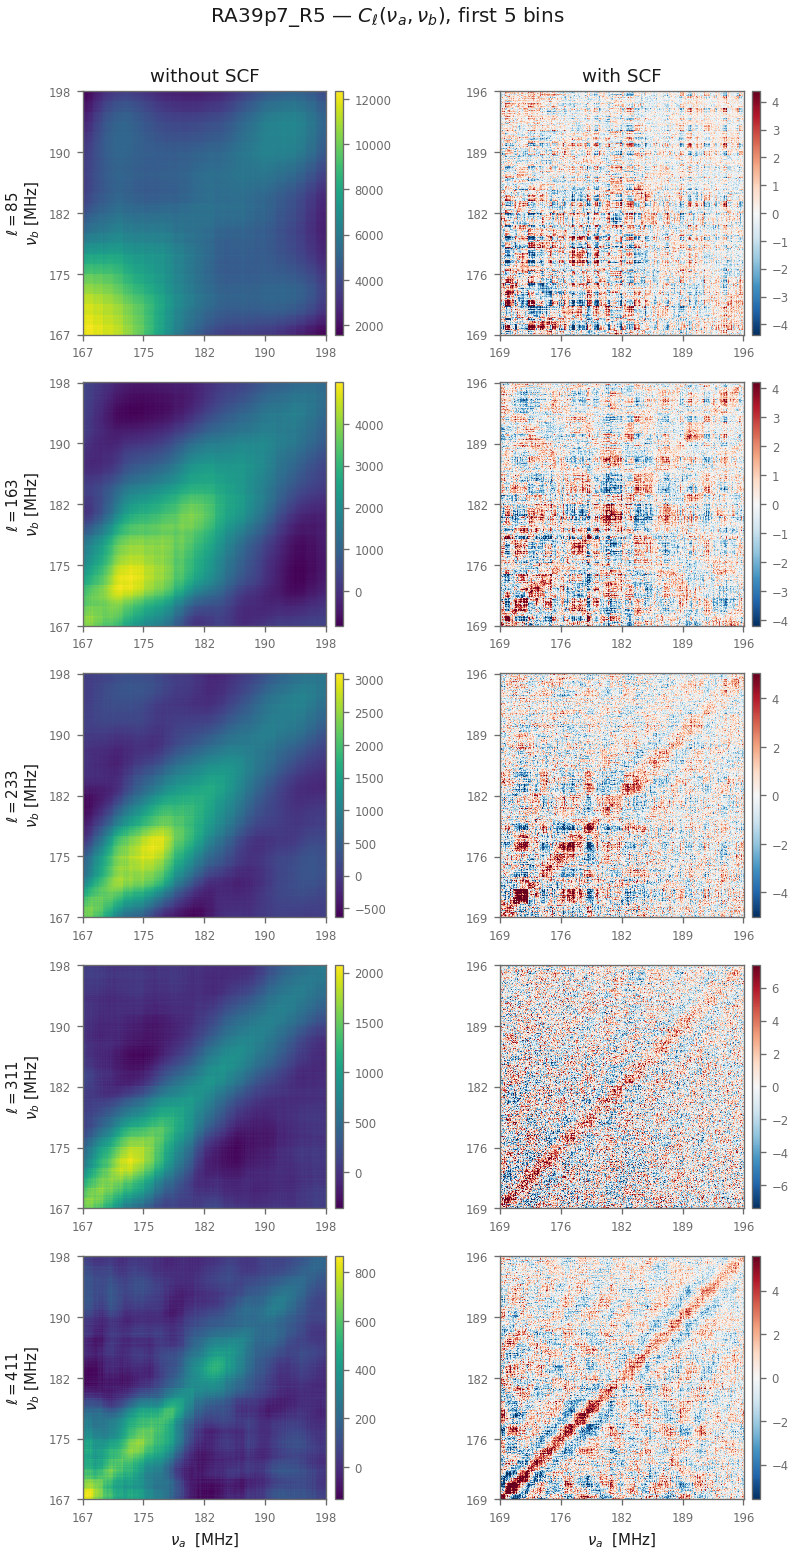

In [10]:
# the first 5 ell bins
mp.compare_cl_nunu(cl2d_runs, lval,
                   cfg.observation.nuc_mhz, cfg.observation.dnuc_mhz,
                   n_bins=5, drop_flagged=True,
                   title=f'{cfg.index} — $C_\\ell(\\nu_a,\\nu_b)$, first 5 bins')

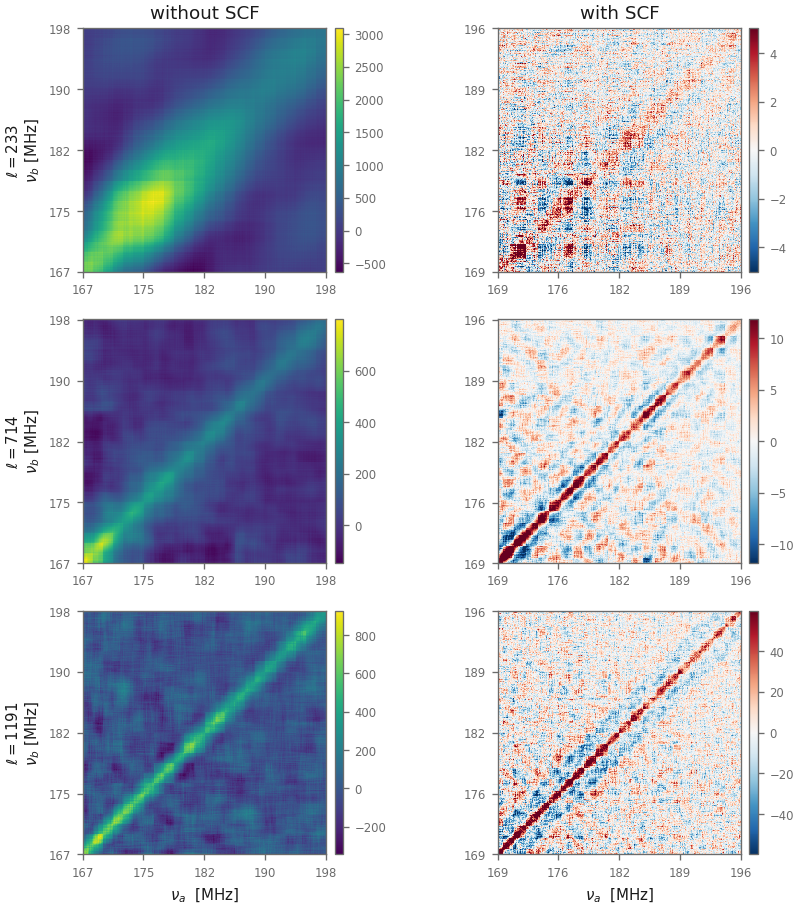

In [11]:
# or name the bins you want
mp.compare_cl_nunu(cl2d_runs, lval,
                   cfg.observation.nuc_mhz, cfg.observation.dnuc_mhz,
                   bins=[2, 8, 14], drop_flagged=True)

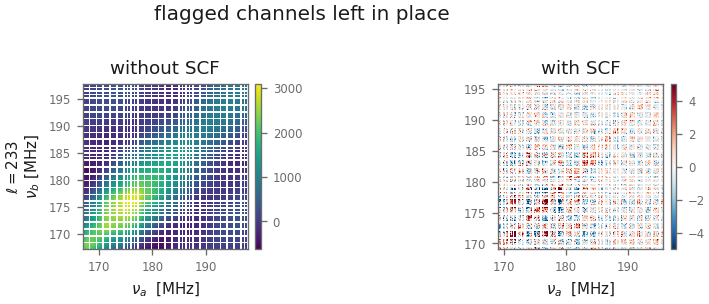

In [12]:
# what the flagged channels look like if you leave them in
mp.compare_cl_nunu(cl2d_runs, lval,
                   cfg.observation.nuc_mhz, cfg.observation.dnuc_mhz,
                   bins=[2], drop_flagged=False,
                   title='flagged channels left in place')

### The full set to disk

All 20 bins, ~25 MB PNG — write it rather than render it inline:

```python
out = cfg.out('plots_compare') / f'compare_cl_nunu_{cfg.index}'
mp.compare_cl_nunu(cl2d_runs, lval, cfg.observation.nuc_mhz,
                   cfg.observation.dnuc_mhz, drop_flagged=True, out=out)
```

## Saving

Pass `out=` to write PDF + PNG, or use the batch stage for the whole set:

```bash
python pipeline/07_compare.py
```

In [13]:
out = cfg.out('plots_compare')
out.mkdir(parents=True, exist_ok=True)

for p in mp.compare_spherical(loaded, out=out / f'compare_spherical_{cfg.index}',
                              reference=REFERENCE):
    print('wrote', p)

wrote /scratch3/users/schatterjee/project_MWA/hyperdrive_residual-R5_HF_RA39p7/ps_run_RA_39p7DEG/plots_compare/compare_spherical_RA39p7_R5.pdf
wrote /scratch3/users/schatterjee/project_MWA/hyperdrive_residual-R5_HF_RA39p7/ps_run_RA_39p7DEG/plots_compare/compare_spherical_RA39p7_R5.png
